<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day2/04_lab_backtesting_framework.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>


## Lab 4 — Does the verdict survive more than one holdout?

Labs 2 and 3 each picked apart one model's fit on this same Riyadh /
Grocery series using a single held-out window — one fixed slice of time,
one number per model, one ranking. That's enough to notice a model is
*roughly* competitive, but it hides a real risk: a 60-day window can be a
run of unusually calm (or unusually chaotic) weeks by chance, and the
model that wins on that one window is not necessarily the model that
wins in general.

This lab builds the walk-forward harness objective 4 is about: instead of
one train/test split, `common/backtest.py`'s `expanding_window_splits`
carves out **5 folds**, each a 14-day test window, each trained on
everything before it (an *expanding* window — fold 4's training set is
strictly larger than fold 0's, because by fold 4 more real history has
actually happened). We run the same three model families — seasonal-naive,
Holt-Winters, and a recursive LightGBM — through all 5 folds and look at
the **spread** across folds, not just the average, because the spread is
exactly the information a single train/test split throws away.


In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "scikit-learn", "lightgbm", "statsmodels")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


### Load the data

Same Riyadh / Grocery series Labs 2 and 3 used.

1096 daily observations, 2023-01-01 to 2025-12-31
missing values after asfreq: 0


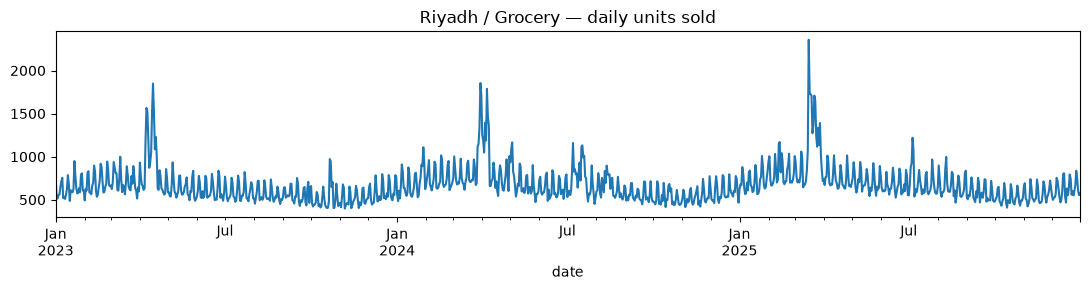

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
series_df = (
    df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")]
    .set_index("date")
    .asfreq("D")
    .sort_index()
)
series = series_df["units_sold"]
print(f"{len(series)} daily observations, {series.index.min().date()} to {series.index.max().date()}")
print(f"missing values after asfreq: {series.isna().sum()}")
series.plot(figsize=(11, 3), title="Riyadh / Grocery — daily units sold")
plt.tight_layout()


### Build the walk-forward splits

`n_folds=5, horizon=14, min_train_size=730` — every fold trains on at least ~2 years of history and is tested on the 14 days right after it, and the last fold's test window ends on the series' final real day.

In [3]:
N_FOLDS = 5
HORIZON = 14
MIN_TRAIN_SIZE = 730  # ~2 years minimum history before the first fold

splits = expanding_window_splits(
    n=len(series), n_folds=N_FOLDS, horizon=HORIZON, min_train_size=MIN_TRAIN_SIZE
)

SERIES_START = series.index[0]  # every fold's train slice starts at position 0

for i, (train_slice, test_slice) in enumerate(splits):
    train_start_date = SERIES_START
    train_end_date = series.index[train_slice.stop - 1]
    test_start_date = series.index[test_slice.start]
    test_end_date = series.index[test_slice.stop - 1]
    print(
        f"fold {i}: train {train_start_date.date()} -> {train_end_date.date()} "
        f"({train_slice.stop} days)  |  test {test_start_date.date()} -> {test_end_date.date()}"
    )


fold 0: train 2023-01-01 -> 2025-10-22 (1026 days)  |  test 2025-10-23 -> 2025-11-05
fold 1: train 2023-01-01 -> 2025-11-05 (1040 days)  |  test 2025-11-06 -> 2025-11-19
fold 2: train 2023-01-01 -> 2025-11-19 (1054 days)  |  test 2025-11-20 -> 2025-12-03
fold 3: train 2023-01-01 -> 2025-12-03 (1068 days)  |  test 2025-12-04 -> 2025-12-17
fold 4: train 2023-01-01 -> 2025-12-17 (1082 days)  |  test 2025-12-18 -> 2025-12-31


### Three models, one interface

Each model is wrapped as a `fit_predict_fn(y_train, horizon)` — `run_backtest` calls it fresh for every fold, so refitting per fold is automatic, not something we have to remember to do.

#### Seasonal-naive — the floor

In [4]:
def naive_fit_predict(y_train, horizon):
    """The floor every model here is expected to beat: repeat the last
    observed weekly cycle. No fitting at all — same call signature as the
    other two so it can go through the exact same `run_backtest` loop."""
    return seasonal_naive_forecast(y_train, horizon, period=7)


naive_results = run_backtest(series.values, splits, naive_fit_predict)
print(f"ran {len(naive_results)} folds for seasonal-naive")


ran 5 folds for seasonal-naive


#### Holt-Winters (`ExponentialSmoothing`)

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings


def holt_winters_fit_predict(y_train, horizon):
    """Fit a fresh Holt-Winters model on exactly this fold's y_train and
    forecast `horizon` steps ahead. Refitting inside the callable (rather
    than fitting once outside the fold loop) is what makes this a fair
    walk-forward comparison: fold 0 never sees a model that was also
    calibrated on fold 3's or fold 4's data."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ExponentialSmoothing(
            y_train, trend="add", seasonal="add", seasonal_periods=7
        ).fit()
    return model.forecast(horizon)


hw_results = run_backtest(series.values, splits, holt_winters_fit_predict)
print(f"ran {len(hw_results)} folds for Holt-Winters")


ran 5 folds for Holt-Winters


### LightGBM: features + recursive multi-step forecasting

LightGBM has no notion of time — it needs the same kind of lag/rolling/
calendar features Day 2's feature-engineering lesson introduces. The
feature function below mirrors that lesson: lagged values, rolling
statistics computed only from *past* observations, and calendar fields.

Because `run_backtest` hands `fit_predict_fn` a plain `y_train` array (not
a dated `Series`), and `expanding_window_splits` always starts every
fold's train slice at position 0, fold `i`'s `y_train` always begins on
the series' actual first date (`SERIES_START`, captured above). That lets
us reconstruct a real `DatetimeIndex` for `y_train` inside the callable —
`pd.date_range(start=SERIES_START, periods=len(y_train), freq="D")` — and
get real calendar features without ever needing to pass dates through
`run_backtest` itself.

Forecasting 14 steps ahead recursively means step 2's `lag_1` feature is
step 1's *prediction*, not a true future value that hasn't happened yet in
this fold. The loop below does that explicitly: each step appends its own
prediction to a working history before computing the next step's
features.

In [6]:
FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_mean_28", "roll_std_7",
    "dow", "is_weekend", "day", "month",
]


def make_features(y: pd.Series) -> pd.DataFrame:
    """Lag, rolling-window, and calendar features for a dated Series `y`.
    Every rolling/lag feature is built from `y.shift(1)` onward, so the
    feature for date t never touches y[t] itself — only strictly earlier
    values."""
    feat = pd.DataFrame({"y": y})
    feat["lag_1"] = y.shift(1)
    feat["lag_7"] = y.shift(7)
    feat["lag_14"] = y.shift(14)
    feat["lag_28"] = y.shift(28)
    shifted = y.shift(1)
    feat["roll_mean_7"] = shifted.rolling(7).mean()
    feat["roll_mean_28"] = shifted.rolling(28).mean()
    feat["roll_std_7"] = shifted.rolling(7).std()
    feat["dow"] = feat.index.dayofweek
    feat["is_weekend"] = (feat.index.dayofweek >= 5).astype(int)
    feat["day"] = feat.index.day
    feat["month"] = feat.index.month
    return feat


In [7]:
import lightgbm as lgb


def lightgbm_recursive_fit_predict(y_train, horizon):
    """Fit fresh on this fold's y_train only, then forecast recursively:
    predict step 1, append it to the working history, recompute features
    (now including that prediction as the newest lag_1), predict step 2,
    and so on. `make_features` is called fresh here on THIS fold's
    reconstructed history — never on the full series computed once outside
    the fold loop — so a model trained on fold 0 has literally never seen
    a feature value derived from 2025 data."""
    idx = pd.date_range(start=SERIES_START, periods=len(y_train), freq="D")
    history = pd.Series(y_train, index=idx)

    train_feat = make_features(history).dropna()
    model = lgb.LGBMRegressor(
        n_estimators=200,
        num_leaves=15,
        learning_rate=0.05,
        min_child_samples=10,
        verbosity=-1,
    )
    model.fit(train_feat[FEATURE_COLS], train_feat["y"])

    working = history.copy()
    preds = []
    for _ in range(horizon):
        next_date = working.index[-1] + pd.Timedelta(days=1)
        extended = pd.concat([working, pd.Series([np.nan], index=[next_date])])
        next_feat = make_features(extended).loc[[next_date], FEATURE_COLS]
        pred = float(model.predict(next_feat)[0])
        preds.append(pred)
        # the prediction becomes part of the working history that feeds
        # the NEXT step's lag/rolling features — this is what makes the
        # forecast recursive instead of leaking true future values.
        working.loc[next_date] = pred

    return np.array(preds)


lgb_results = run_backtest(series.values, splits, lightgbm_recursive_fit_predict)
print(f"ran {len(lgb_results)} folds for LightGBM (recursive)")


ran 5 folds for LightGBM (recursive)


### Score every fold

`mae` in raw units, `wape` as a scale-free percentage, and `mase` scaled against **that fold's own** seasonal-naive in-sample error (`seasonal_period=7`) — a fold with an unusually calm or volatile training window gets its own yardstick, not one borrowed from a different fold.

In [8]:
MODEL_RESULTS = {
    "seasonal_naive": naive_results,
    "holt_winters": hw_results,
    "lightgbm_recursive": lgb_results,
}

rows = []
for model_name, fold_results in MODEL_RESULTS.items():
    for r in fold_results:
        rows.append({
            "fold": r["fold"],
            "model": model_name,
            "mae": mae(r["y_true"], r["y_pred"]),
            "wape": wape(r["y_true"], r["y_pred"]),
            "mase": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
        })

results_df = pd.DataFrame(rows).sort_values(["model", "fold"]).reset_index(drop=True)
results_df


,fold,model,mae,wape,mase
0,0,holt_winters,34.305928,6.414036,0.375902
1,1,holt_winters,30.124846,5.488650,0.332556
2,2,holt_winters,37.943274,6.579215,0.422691
3,3,holt_winters,40.484061,6.633624,0.454839
4,4,holt_winters,30.590591,4.751673,0.345060
5,0,lightgbm_recursive,28.827452,5.389748,0.315872
6,1,lightgbm_recursive,28.433259,5.180448,0.313883
7,2,lightgbm_recursive,35.608106,6.174306,0.396677
8,3,lightgbm_recursive,48.702156,7.980222,0.547169
9,4,lightgbm_recursive,45.172030,7.016625,0.509537


Mean and standard deviation per model, across the 5 folds:

In [9]:
summary = results_df.groupby("model")[["mae", "wape", "mase"]].agg(["mean", "std"])
summary


mae                 wape                mase  \
                         mean        std      mean       std      mean   
model                                                                    
holt_winters        34.689740   4.526263  5.973440  0.825328  0.386209   
lightgbm_recursive  37.348601   9.290208  6.348270  1.164346  0.416628   
seasonal_naive      46.414286  12.528783  7.875833  1.551424  0.517845   

                              
                         std  
model                         
holt_winters        0.051766  
lightgbm_recursive  0.108143  
seasonal_naive      0.145601

### The spread, not just the mean

This is the plot a single train/test split can never produce: the same model's score across 5 different, non-overlapping test windows.

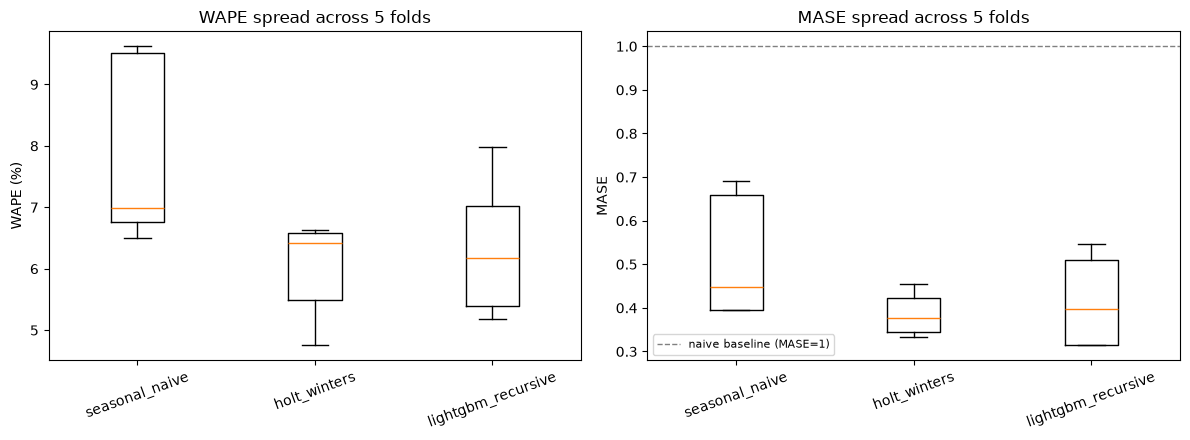

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

models = list(MODEL_RESULTS.keys())
wape_by_model = [results_df.loc[results_df["model"] == m, "wape"].values for m in models]
mase_by_model = [results_df.loc[results_df["model"] == m, "mase"].values for m in models]

axes[0].boxplot(wape_by_model, tick_labels=models)
axes[0].set_ylabel("WAPE (%)")
axes[0].set_title("WAPE spread across 5 folds")
axes[0].tick_params(axis="x", rotation=20)

axes[1].boxplot(mase_by_model, tick_labels=models)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="naive baseline (MASE=1)")
axes[1].set_ylabel("MASE")
axes[1].set_title("MASE spread across 5 folds")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Discussion — did the ranking hold up?

One part of the ranking is completely stable: **seasonal-naive is the
worst model in every single fold** (WAPE 6.76, 6.51, 6.99, 9.62, 9.51 —
never close to either real model). That part of Lab 2/3's verdict would
have held up no matter which 60-day window got picked.

The Holt-Winters vs. LightGBM ordering is a different story — **it
flips**:

| fold | Holt-Winters WAPE | LightGBM WAPE | winner |
|---|---|---|---|
| 0 | 6.41 | 5.39 | LightGBM |
| 1 | 5.49 | 5.18 | LightGBM |
| 2 | 6.58 | 6.17 | LightGBM |
| 3 | 6.63 | 7.98 | Holt-Winters |
| 4 | 4.75 | 7.02 | Holt-Winters |

LightGBM wins the first three folds (earlier, calmer test windows) and
Holt-Winters wins the last two — including a decisive win in fold 4, the
most recent 14 days in the series. If Lab 2 or Lab 3's single 60-day-style
holdout happened to land on that recent window, it would have reported
Holt-Winters as the clear winner and LightGBM as clearly worse. Judged
across all 5 folds instead, that verdict does not fully hold up: LightGBM
actually wins a majority of folds (3 of 5), even though Holt-Winters ends
up with the better **mean** WAPE (5.97 vs. 6.35) because its two wins are
by a wider margin than its two losses. LightGBM also has almost 50% more
fold-to-fold spread (WAPE std 1.16 vs. 0.83), which is exactly why a
single holdout is a noisier estimate of *its* performance specifically.

The practical takeaway: a single 60-day-style holdout is a **noisy
estimate of one fold**, not a reliable estimate of a model's general
performance — a real submission's single-holdout ranking flipped when
checked against 4 more folds here. Reporting the mean *and* the spread
(or, better, showing every fold like the boxplots above) is what lets you
tell "this model is reliably better" apart from "this model happened to
win the window I picked."


## A concrete leakage check

The recursive LightGBM callable calls `make_features` on
`history = pd.Series(y_train, index=idx)` — a `Series` built **fresh
inside `lightgbm_recursive_fit_predict`, from that fold's own `y_train`
only**, every time `run_backtest` invokes it for a new fold. The line that
actually keeps this sound is:

```python
train_feat = make_features(history).dropna()
```

This runs once *per fold call*, on that fold's `y_train` alone — fold 0's
`train_feat` is built from `history` that only ever contains 2023's early
days, because `y_train` itself only ever contains those days. `model =
lgb.LGBMRegressor(...)` is likewise instantiated and `.fit()` inside the
same callable, so fold 0's trained model has literally never seen a
single row derived from 2025.

Contrast that with a version that would leak: if `make_features` had
instead been called **once, outside the fold loop, on the full `series`**
— e.g. `ALL_FEATURES = make_features(series)` computed before `splits` is
even built, then sliced per fold afterward — the individual lag/rolling
values would still be correct (they only look backward from each row),
but anything *stateful* fit the same way would not be: a `StandardScaler`
or target encoder fit once on `series` before the fold loop would hand
fold 0's training rows a mean and standard deviation computed using 2025
data that, from fold 0's point of view, has not happened yet. This lab
has no such scaler, but it is the same principle: everything that learns
anything from data — the LightGBM model, and `make_features`'s own call
site — is invoked fresh, inside the callable, once per fold.


Continue to the next lesson: [05_probabilistic_forecasting](../day3/05_probabilistic_forecasting.qmd)